[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-1/router.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239412-lesson-5-router)

# Router

## Review

We built a graph that uses `messages` as state and a chat model with bound tools.

We saw that the graph can:

* Return a tool call
* Return a natural language response

## Goals

We can think of this as a router, where the chat model routes between a direct response or a tool call based upon the user input.

This is a simple example of an agent, where the LLM is directing the control flow either by calling a tool or just responding directly. 

![Screenshot 2024-08-21 at 9.24.09 AM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbac6543c3d4df239a4ed1_router1.png)

Let's extend our graph to work with either output! 

For this, we can use two ideas:

(1) Add a node that will call our tool.

(2) Add a conditional edge that will look at the chat model output, and route to our tool calling node or simply end if no tool call is performed. 



In [ ]:
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_core langgraph langgraph-prebuilt

In [6]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")
_set_env("OPENAI_BASE_URL")

OPENAI_BASE_URL:  ········


In [7]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm = ChatOpenAI(model="gpt-4o")
llm_with_tools = llm.bind_tools([multiply])

 We use the  [built-in `ToolNode`](https://langchain-ai.github.io/langgraph/reference/agents/#langgraph.prebuilt.tool_node.ToolNode) and simply pass a list of our tools to initialize it. 
 
 We use the [built-in `tools_condition`](https://langchain-ai.github.io/langgraph/reference/agents/#langgraph.prebuilt.tool_node.tools_condition) as our conditional edge.

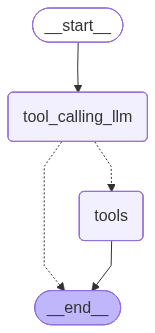

In [8]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode([multiply]))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
from langchain_core.messages import HumanMessage
messages = [HumanMessage(content="what is 5 multiply 2?")]
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 5 multiply 2?
================================== Ai Message ==================================
Tool Calls:
  multiply (HRWpfzuRjYiQmYlc3eSPMzXdTsBFGk4u)
 Call ID: HRWpfzuRjYiQmYlc3eSPMzXdTsBFGk4u
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [12]:
message_image = HumanMessage(content=[
    {"type": "text", "text": "Describe this image?"},
    {"type": "image", "url": "https://raw.githubusercontent.com/google-gemma/cookbook/refs/heads/main/apps/sample-data/GoldenGate.png"},
])
messages = graph.invoke({"messages": [message_images]})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

[{'type': 'text', 'text': 'Describe this image?'}, {'type': 'image', 'url': 'https://raw.githubusercontent.com/google-gemma/cookbook/refs/heads/main/apps/sample-data/GoldenGate.png'}]
================================== Ai Message ==================================

This image is a scenic photograph prominently featuring the **Golden Gate Bridge**.

Here is a detailed description:

**The Subject:** The focal point of the image is the magnificent, vibrant orange/red suspension bridge, with its tall towers and intricate cable structure stretching across a wide expanse of water. The bridge dominates the middle ground of the frame.

**The Setting:** The scene is coastal and bathed in bright daylight. In the foreground, there is a rocky shoreline with dark, wet rocks meeting the calm, deep blue water of a bay or ocean. The water reflects the clear sky, creating a serene contrast to the massive structure above.


In [13]:
message_audio = HumanMessage(content=[
    {"type": "text", "text": "Transcribe the following speech segment in its original language. Follow these specific instructions for formatting the answer:\n* Only output the transcription, with no newlines.\n* When transcribing numbers, write the digits, i.e. write 1.7 and not one point seven, and write 3 instead of three."},
    {"type": "audio", "url": "https://github.com/google-gemma/cookbook/raw/refs/heads/main/apps/sample-data/journal1.wav"},
])
messages = graph.invoke({"messages": [message_audio]})
for m in messages['messages']:
    m.pretty_print()

ValueError: Key base64 is required for audio blocks.

Now, we can see that the graph runs the tool!

It responds with a `ToolMessage`. 

## Studio

**⚠️ Notice**

Since filming these videos, we've updated Studio so that it can now be run locally and accessed through your browser. This is the preferred way to run Studio instead of using the Desktop App shown in the video. It is now called _LangSmith Studio_ instead of _LangGraph Studio_. Detailed setup instructions are available in the "Getting Setup" guide at the start of the course. You can find a description of Studio [here](https://docs.langchain.com/langsmith/studio), and specific details for local deployment [here](https://docs.langchain.com/langsmith/quick-start-studio#local-development-server).  
To start the local development server, run the following command in your terminal in the `/studio` directory in this module:

```
langgraph dev
```

You should see the following output:
```
- 🚀 API: http://127.0.0.1:2024
- 🎨 Studio UI: https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
- 📚 API Docs: http://127.0.0.1:2024/docs
```

Open your browser and navigate to the Studio UI shown above.
Load the `router` in Studio, which uses `module-1/studio/router.py` set in `module-1/studio/langgraph.json`.

In [7]:
if 'google.colab' in str(get_ipython()):
    raise Exception("Unfortunately LangGraph Studio is currently not supported on Google Colab")